This file achieves similar objectives as the other file. However, this file calls SAM3 through a helper function. This is done to help organize the workflow when integrated with OpenPIV. 

In [1]:
import os
from Scripts.SAM3Interface import SAM3Mask
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch

/home/leo/sam3/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/leo/miniforge3/envs/SAM3OpenPIV/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


This step reads the input image and starts the SAM3 function, the output is the mask in boolean numpy array

In [2]:
Name1="Frame_00001.tif" #Change name for PIV image used to generate mask
InputPath=os.path.join(os.getcwd(),"input")
GenPath=os.path.join(os.getcwd(),"input",Name1)

MaskOut=SAM3Mask(GenPath,"Black Shape")


Is CUDA available: True
Current device: 0
Device name: NVIDIA GeForce RTX 3070 Laptop GPU
Processing images from: /home/leo/SAM3OpenPIV/SAM3-Masking-for-OpenPIV/input/Frame_00001.tif
Depth: 2052
Height: 4603
Width: 3
Detected
tensor([0.9492], device='cuda:0', dtype=torch.bfloat16)


Visualize the Mask

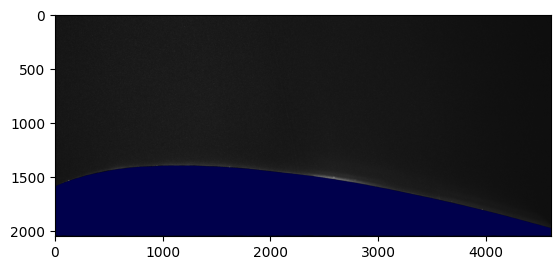

In [3]:
Source = cv2.imread(GenPath)

CroppedMask=MaskOut.astype(np.uint8) * 255
color_mask = cv2.cvtColor(CroppedMask, cv2.COLOR_GRAY2BGR)
color_mask[MaskOut] = [255, 0, 0] # Blue BGR

img = cv2.addWeighted(color_mask, 0.3, Source, 1, 0)

image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)

In [4]:
torch.cuda.empty_cache()